## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
from matplotlib.lines import Line2D
from functions import *

# WARNINGS
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="pkg_resources")

In [2]:
project_root = find_project_root()
experiments_dir = project_root / "notebooks" / "experiments"
if str(experiments_dir.resolve()) not in sys.path:
    sys.path.insert(0, str(experiments_dir.resolve()))

from color_palette import MODEL_ORDER, SHOT_ORDER, MODEL_PALETTE, ordered_levels, DOMAIN_ORDER

sns.set(style="whitegrid")

FONT_CONFIG = {
    'axes_title_size': 23,
    'axes_label_size': 20,
    'legend_size': 17,
    'tick_size': 20,
    'figure_title_size': 30,
    'axes_title_pad': 18,
}

plt.rcParams.update({
    "figure.dpi": 300,
})


PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "analysis" / "bias"
FIGURES_DIR = PROJECT_ROOT / "figures"

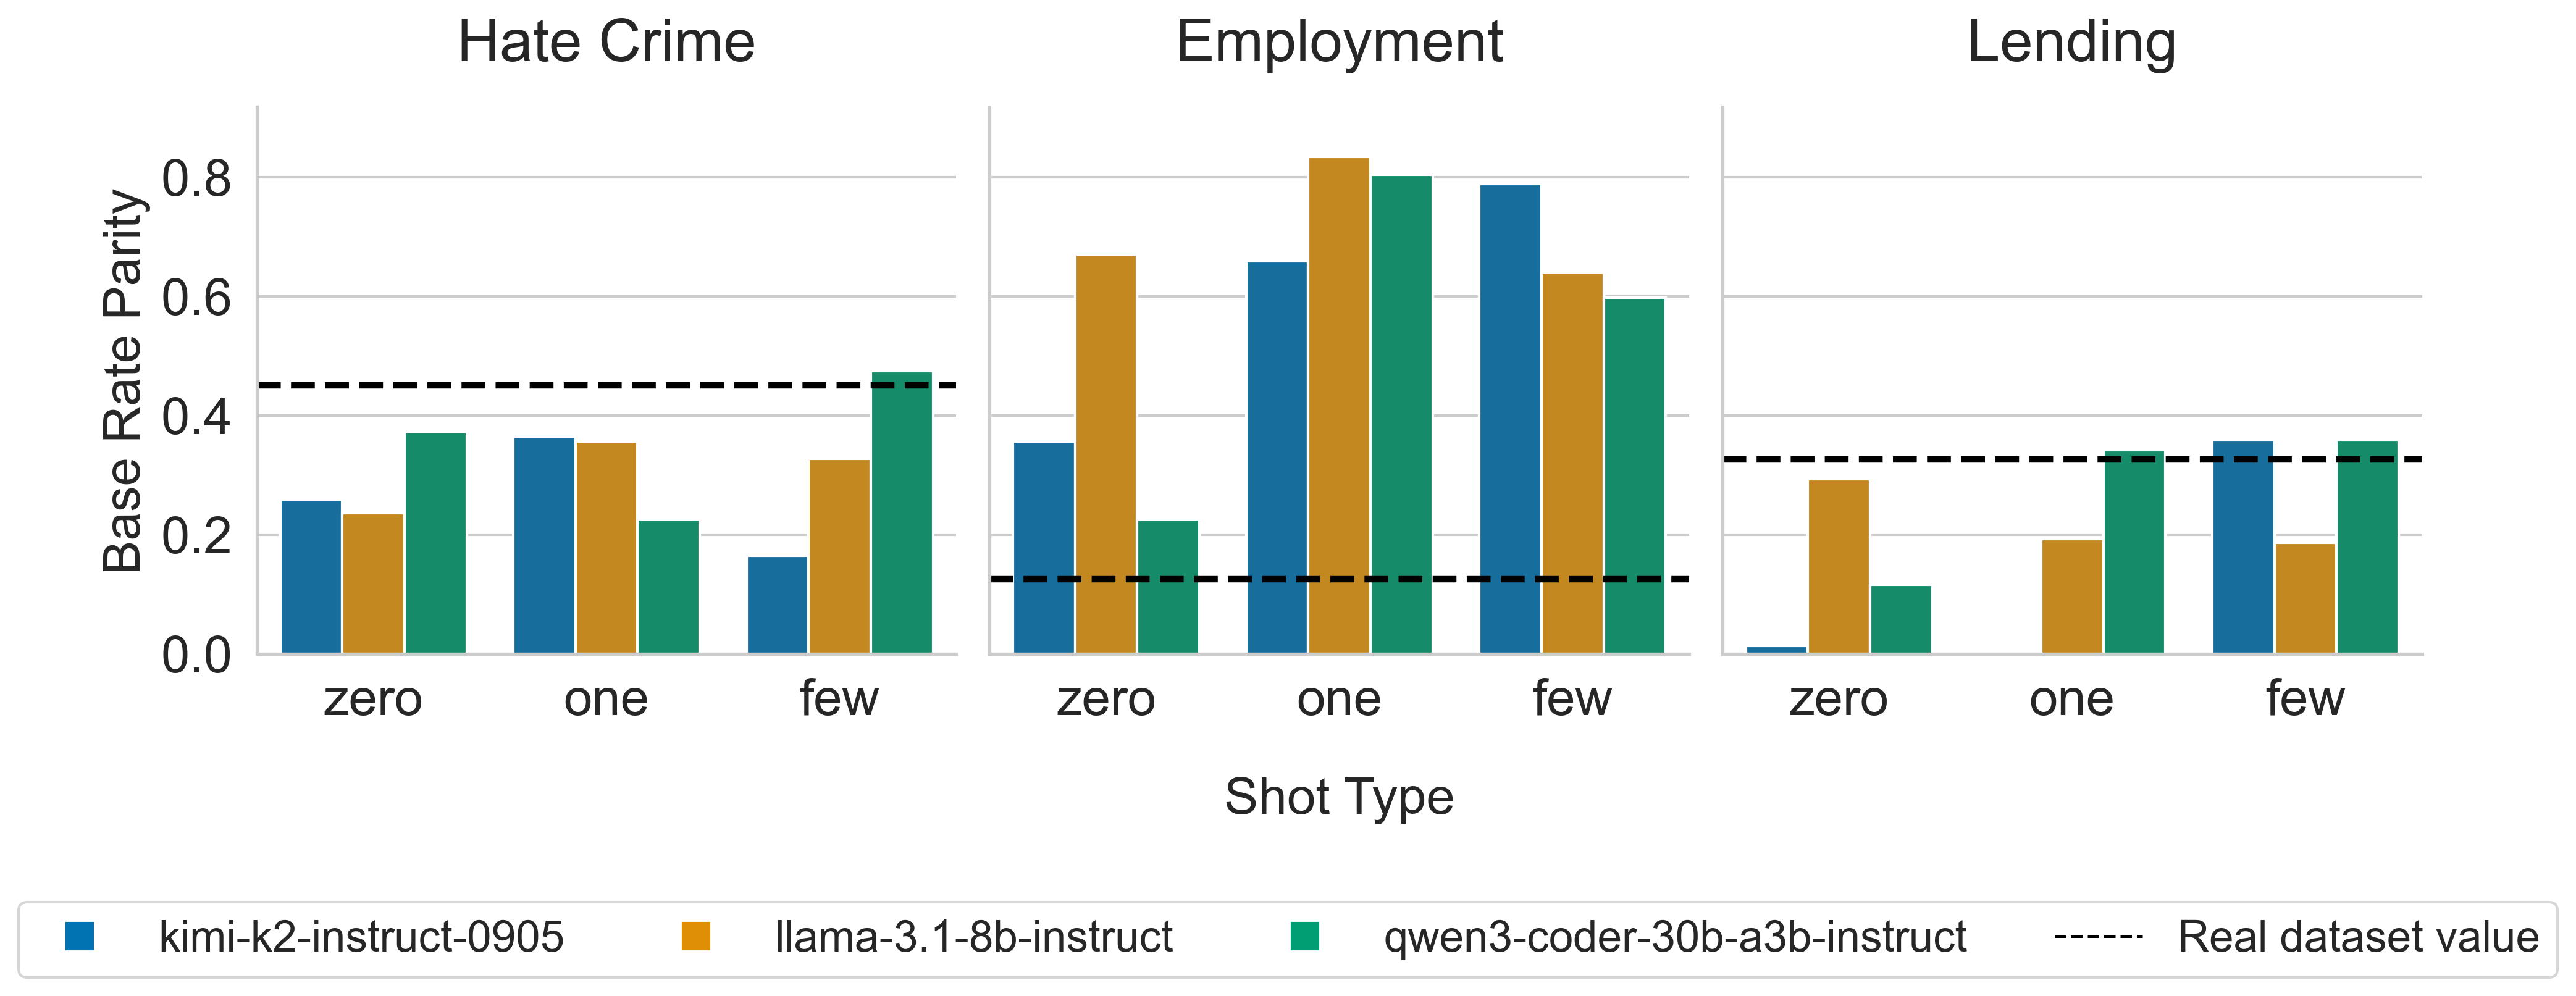

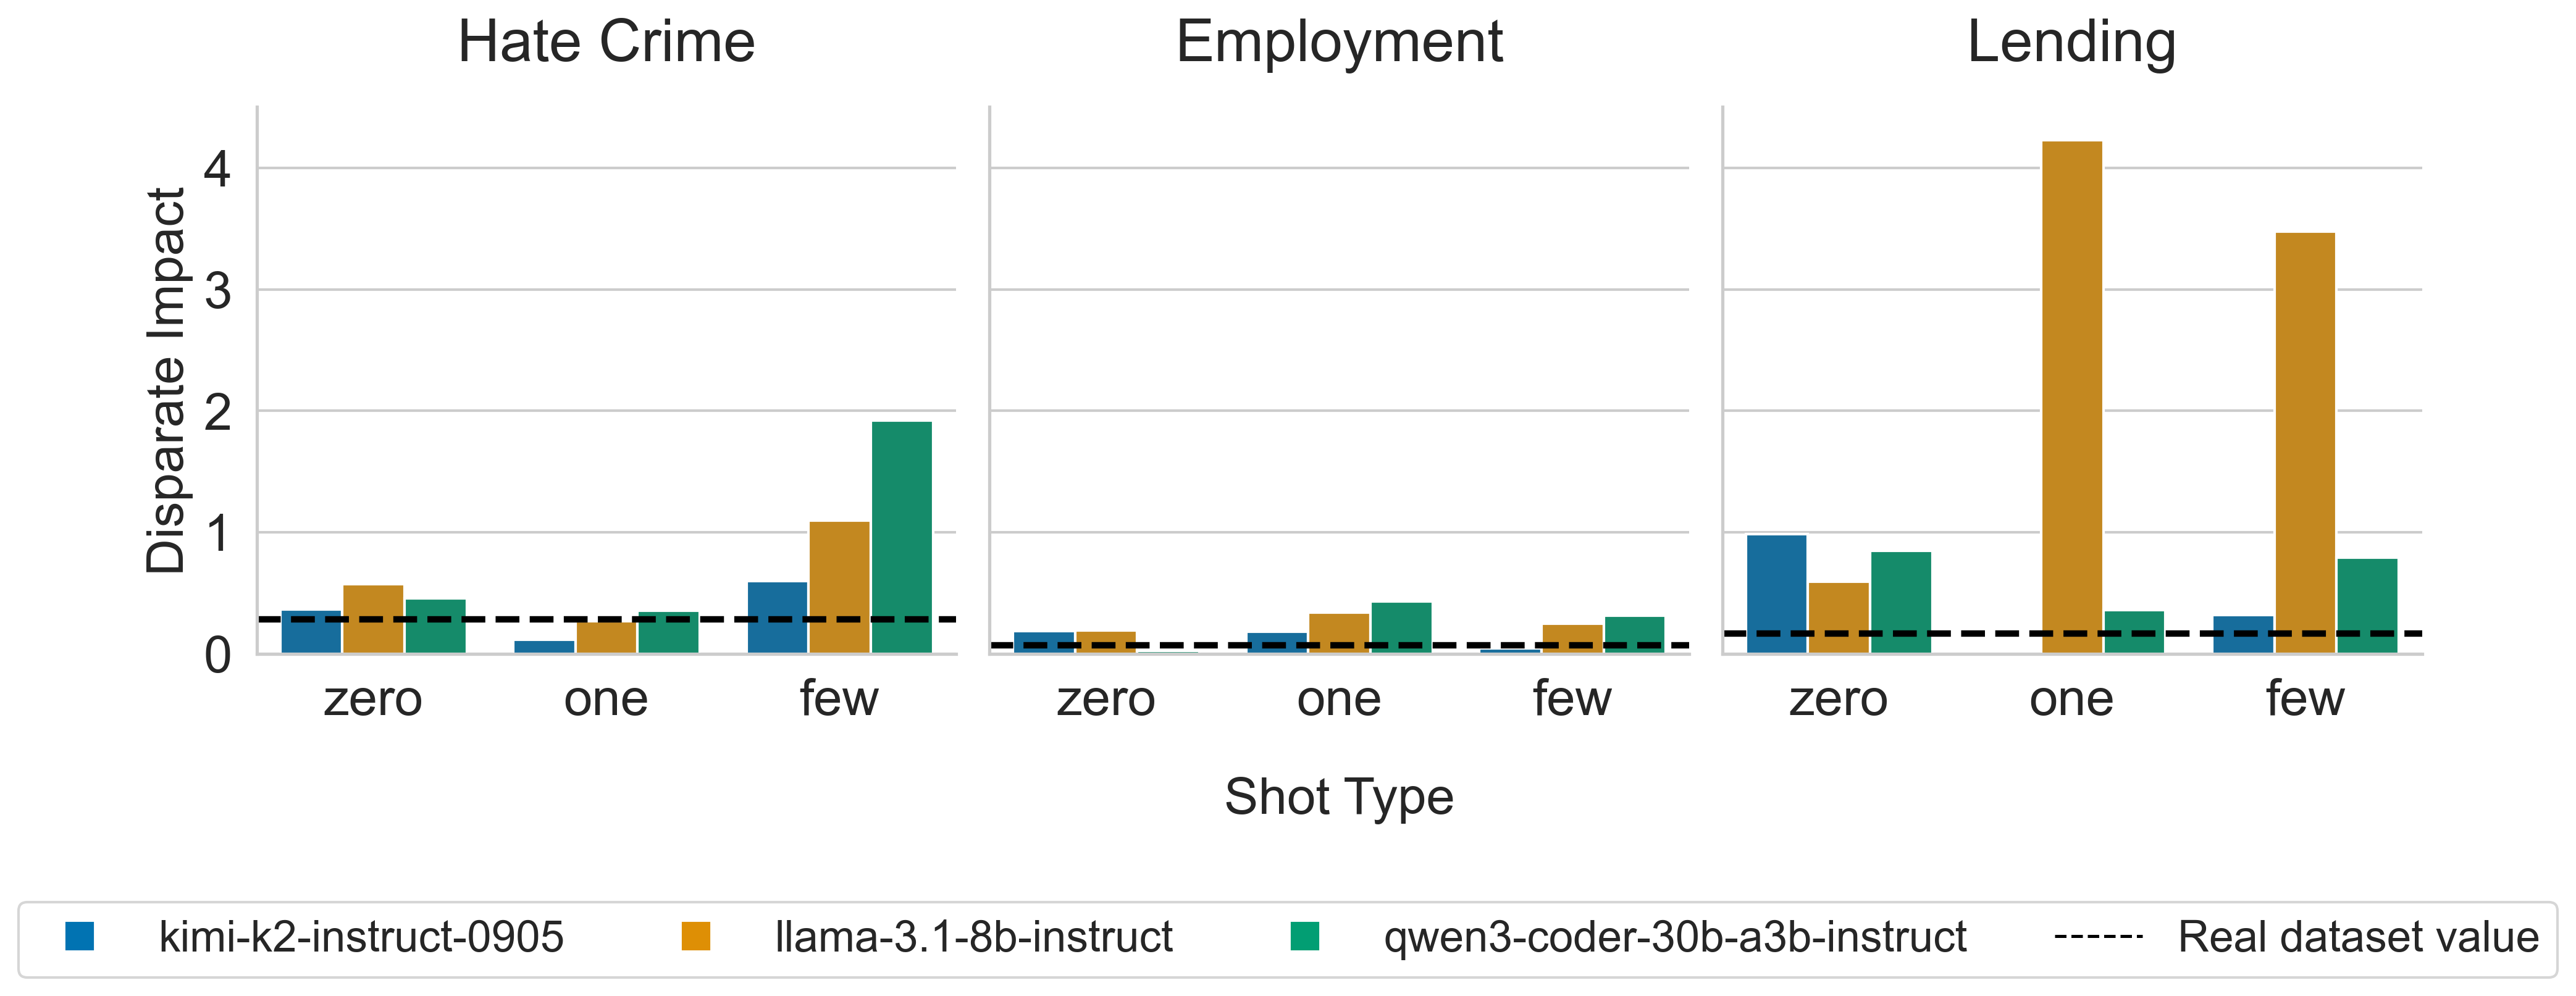

In [3]:
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of {candidates} found in columns {list(df.columns)}")


emp_bp_df = pd.read_csv(RESULTS_DIR / "employment_e01_base_rate_parity.csv")
emp_di_df = pd.read_csv(RESULTS_DIR / "employment_e02_disparate_impact.csv")
emp_md_df = pd.read_csv(RESULTS_DIR / "employment_e03_mean_difference.csv")
emp_real   = pd.read_csv(RESULTS_DIR / "employment_real_metrics.csv")

emp_bp_col = pick_col(emp_bp_df, ["bp_avg"])
emp_di_col = pick_col(emp_di_df, ["di_avg"])
emp_md_col = pick_col(emp_md_df, ["md_avg"])

emp_bp_real = emp_real[pick_col(emp_real, ["bp_avg"])].iloc[0]
emp_di_real = emp_real[pick_col(emp_real, ["di_avg"])].iloc[0]
emp_md_real = emp_real[pick_col(emp_real, ["md_avg"])].iloc[0]


lend_bp_df = pd.read_csv(RESULTS_DIR / "lending_e01_base_rate_parity.csv")
lend_di_df = pd.read_csv(RESULTS_DIR / "lending_e02_disparate_impact.csv")
lend_br_df = pd.read_csv(RESULTS_DIR / "lending_e03_base_rate.csv")
lend_real  = pd.read_csv(RESULTS_DIR / "lending_real_metrics.csv")

lend_bp_col = pick_col(lend_bp_df, ["bp_overall"])
lend_di_col = pick_col(lend_di_df, ["di_overall"])
lend_br_col = pick_col(lend_br_df, ["br_overall"])

lend_bp_real = lend_real[pick_col(lend_real, ["overall_brp"])].iloc[0]
lend_di_real = lend_real[pick_col(lend_real, ["overall_di"])].iloc[0]
lend_br_real = lend_real[pick_col(lend_real, ["overall_br"])].iloc[0]


hc_bp_df = pd.read_csv(RESULTS_DIR / "hatecrime_e01_base_rate_parity.csv")
hc_di_df = pd.read_csv(RESULTS_DIR / "hatecrime_e02_disparate_impact.csv")
hc_br_df = pd.read_csv(RESULTS_DIR / "hatecrime_e03_base_rate.csv")
hc_real  = pd.read_csv(RESULTS_DIR / "hatecrime_real_metrics.csv")

hc_bp_col = pick_col(hc_bp_df, ["brp_overall"])
hc_di_col = pick_col(hc_di_df, ["di_overall"])
hc_br_col = pick_col(hc_br_df, ["br_overall"])

hc_bp_real = hc_real[pick_col(hc_real, ["overall_brp"])].iloc[0]
hc_di_real = hc_real[pick_col(hc_real, ["overall_di"])].iloc[0]
hc_br_real = hc_real[pick_col(hc_real, ["overall_br"])].iloc[0]


hc_bp_plot = hc_bp_df.copy()
hc_bp_plot["domain"] = "hatecrime"
hc_bp_plot = hc_bp_plot.rename(columns={hc_bp_col: "value"})

emp_bp_plot = emp_bp_df.copy()
emp_bp_plot["domain"] = "employment"
emp_bp_plot = emp_bp_plot.rename(columns={emp_bp_col: "value"})

lend_bp_plot = lend_bp_df.copy()
lend_bp_plot["domain"] = "lending"
lend_bp_plot = lend_bp_plot.rename(columns={lend_bp_col: "value"})

bp_all_plot = pd.concat([hc_bp_plot, emp_bp_plot, lend_bp_plot], ignore_index=True)
bp_all_plot = bp_all_plot.groupby(["domain", "model", "shot"], as_index=False)["value"].mean()

bp_all_plot["domain"] = pd.Categorical(bp_all_plot["domain"], categories=DOMAIN_ORDER, ordered=True)
bp_all_plot["model"] = pd.Categorical(bp_all_plot["model"], categories=MODEL_ORDER, ordered=True)
bp_all_plot["shot"] = pd.Categorical(bp_all_plot["shot"], categories=SHOT_ORDER, ordered=True)

models = ordered_levels(bp_all_plot["model"].unique(), MODEL_ORDER)
domains = ordered_levels(bp_all_plot["domain"].unique(), DOMAIN_ORDER)

real_values_bp = {
    "hatecrime": hc_bp_real,
    "employment": emp_bp_real,
    "lending": lend_bp_real,
}

g_bp = sns.catplot(
    data=bp_all_plot,
    kind="bar",
    x="shot",
    y="value",
    hue="model",
    col="domain",
    order=SHOT_ORDER,
    hue_order=models,
    col_order=domains,
    palette=MODEL_PALETTE,
    height=4,
    aspect=1.05,
    sharey=True,
    legend=False,
)

g_bp.fig.set_size_inches(4 * 1.05 * len(domains), 4)

g_bp.set_titles("{col_name}")

y_max = bp_all_plot["value"].max()
y_max = max(y_max * 1.1, max(real_values_bp.values()) * 1.1)

for i, (ax, domain) in enumerate(zip(g_bp.axes.flat, domains)):
    baseline = real_values_bp.get(domain)
    if baseline is not None:
        ax.axhline(
            y=baseline,
            color="black",
            linestyle="--",
            linewidth=2.5,
        )
    
    ax.set_title(
        format_domain_name(domain),
        fontsize=FONT_CONFIG['axes_title_size'],
        pad=FONT_CONFIG['axes_title_pad'],
    )
    if i == len(domains) // 2:
        ax.set_xlabel("Shot Type", fontsize=FONT_CONFIG['axes_label_size'], labelpad=20)
    else:
        ax.set_xlabel("", fontsize=FONT_CONFIG['axes_label_size'])
    ax.set_ylabel("Base Rate Parity", fontsize=FONT_CONFIG['axes_label_size'])
    ax.tick_params(axis='both', labelsize=FONT_CONFIG['tick_size'])
    ax.set_ylim(0, y_max)

handles_bp = [
    Line2D([0], [0], marker="s", linestyle="none", markersize=10, color=MODEL_PALETTE[model], label=model)
    for model in models
]

baseline_handle = Line2D(
    [0], [0], color="black", linestyle="--", linewidth=1.2, label="Real dataset value"
)
handles_bp.append(baseline_handle)
labels_bp = list(models) + ["Real dataset value"]

g_bp.fig.legend(
    handles_bp,
    labels_bp,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=max(1, len(models) + 1),
    fontsize=FONT_CONFIG['legend_size'],
    frameon=True,
)

plt.savefig(FIGURES_DIR / "brp_all_domains.png", dpi=300, bbox_inches='tight')
plt.show()


emp_di_df_transformed = emp_di_df.copy()
emp_di_df_transformed[emp_di_col] = (emp_di_df[emp_di_col] - 1.0).abs()
emp_di_real_transformed = abs(emp_di_real - 1.0)

lend_di_df_transformed = lend_di_df.copy()
lend_di_df_transformed[lend_di_col] = (lend_di_df[lend_di_col] - 1.0).abs()
lend_di_real_transformed = abs(lend_di_real - 1.0)

hc_di_df_transformed = hc_di_df.copy()
hc_di_df_transformed[hc_di_col] = (hc_di_df[hc_di_col] - 1.0).abs()
hc_di_real_transformed = abs(hc_di_real - 1.0)

hc_di_plot = hc_di_df_transformed.copy()
hc_di_plot["domain"] = "hatecrime"
hc_di_plot = hc_di_plot.rename(columns={hc_di_col: "value"})

emp_di_plot = emp_di_df_transformed.copy()
emp_di_plot["domain"] = "employment"
emp_di_plot = emp_di_plot.rename(columns={emp_di_col: "value"})

lend_di_plot = lend_di_df_transformed.copy()
lend_di_plot["domain"] = "lending"
lend_di_plot = lend_di_plot.rename(columns={lend_di_col: "value"})

di_all_plot = pd.concat([hc_di_plot, emp_di_plot, lend_di_plot], ignore_index=True)
di_all_plot = di_all_plot.groupby(["domain", "model", "shot"], as_index=False)["value"].mean()

di_all_plot["domain"] = pd.Categorical(di_all_plot["domain"], categories=DOMAIN_ORDER, ordered=True)
di_all_plot["model"] = pd.Categorical(di_all_plot["model"], categories=MODEL_ORDER, ordered=True)
di_all_plot["shot"] = pd.Categorical(di_all_plot["shot"], categories=SHOT_ORDER, ordered=True)

models = ordered_levels(di_all_plot["model"].unique(), MODEL_ORDER)
domains = ordered_levels(di_all_plot["domain"].unique(), DOMAIN_ORDER)

real_values_di = {
    "hatecrime": hc_di_real_transformed,
    "employment": emp_di_real_transformed,
    "lending": lend_di_real_transformed,
}

g_di = sns.catplot(
    data=di_all_plot,
    kind="bar",
    x="shot",
    y="value",
    hue="model",
    col="domain",
    order=SHOT_ORDER,
    hue_order=models,
    col_order=domains,
    palette=MODEL_PALETTE,
    height=4,
    aspect=1.05,
    sharey=True,
    legend=False,
)

g_di.fig.set_size_inches(4 * 1.05 * len(domains), 4)

g_di.set_titles("{col_name}")

for i, (ax, domain) in enumerate(zip(g_di.axes.flat, domains)):
    baseline = real_values_di.get(domain)
    if baseline is not None:
        ax.axhline(
            y=baseline,
            color="black",
            linestyle="--",
            linewidth=2.5,
        )
    
    ax.set_title(
        format_domain_name(domain),
        fontsize=FONT_CONFIG['axes_title_size'],
        pad=FONT_CONFIG['axes_title_pad'],
    )
    if i == len(domains) // 2:
        ax.set_xlabel("Shot Type", fontsize=FONT_CONFIG['axes_label_size'], labelpad=20)
    else:
        ax.set_xlabel("", fontsize=FONT_CONFIG['axes_label_size'])
    ax.set_ylabel("Disparate Impact", fontsize=FONT_CONFIG['axes_label_size'])
    ax.tick_params(axis='both', labelsize=FONT_CONFIG['tick_size'])
    ax.set_ylim(0, 4.5)

handles_di = [
    Line2D([0], [0], marker="s", linestyle="none", markersize=10, color=MODEL_PALETTE[model], label=model)
    for model in models
]

baseline_handle = Line2D(
    [0], [0], color="black", linestyle="--", linewidth=1.2, label="Real dataset value"
)
handles_di.append(baseline_handle)
labels_di = list(models) + ["Real dataset value"]

g_di.fig.legend(
    handles_di,
    labels_di,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=max(1, len(models) + 1),
    fontsize=FONT_CONFIG['legend_size'],
    frameon=True,
)

plt.savefig(FIGURES_DIR / "di_all_domains.png", dpi=300, bbox_inches='tight')
plt.show()


def best_per_graph(df, value_col, real_value, domain, metric_name):
    agg = df.groupby(["model", "shot"], as_index=False)[value_col].mean()
    agg["abs_diff"] = (agg[value_col] - real_value).abs()
    best_row = agg.loc[agg["abs_diff"].idxmin()]
    return {
        "Domain": domain,
        "Metric": metric_name,
        "Model": best_row["model"],
        "Shot": best_row["shot"],
        "Value": best_row[value_col],
        "Real": real_value,
        "AbsDiff": best_row["abs_diff"],
    }

best_rows = []



best_rows.append(best_per_graph(hc_bp_df, hc_bp_col, hc_bp_real,
                                "hatecrime", "BRP"))
best_rows.append(best_per_graph(hc_di_df, hc_di_col, hc_di_real,
                                "hatecrime", "DI"))

best_rows.append(best_per_graph(emp_bp_df, emp_bp_col, emp_bp_real,
                                "employment", "BRP"))
best_rows.append(best_per_graph(emp_di_df, emp_di_col, emp_di_real,
                                "employment", "DI"))


best_rows.append(best_per_graph(lend_bp_df, lend_bp_col, lend_bp_real,
                                "lending", "BRP"))
best_rows.append(best_per_graph(lend_di_df, lend_di_col, lend_di_real,
                                "lending", "DI"))


best_df = pd.DataFrame(best_rows)

In [4]:
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of {candidates} found in columns {list(df.columns)}")


PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "analysis" / "bias"

emp_bp_df = pd.read_csv(RESULTS_DIR / "employment_e01_base_rate_parity.csv")
emp_di_df = pd.read_csv(RESULTS_DIR / "employment_e02_disparate_impact.csv")
emp_md_df = pd.read_csv(RESULTS_DIR / "employment_e03_mean_difference.csv")
emp_real   = pd.read_csv(RESULTS_DIR / "employment_real_metrics.csv")

emp_bp_col = pick_col(emp_bp_df, ["bp_avg"])
emp_di_col = pick_col(emp_di_df, ["di_avg"])
emp_md_col = pick_col(emp_md_df, ["md_avg"])


lend_bp_df = pd.read_csv(RESULTS_DIR / "lending_e01_base_rate_parity.csv")
lend_di_df = pd.read_csv(RESULTS_DIR / "lending_e02_disparate_impact.csv")
lend_br_df = pd.read_csv(RESULTS_DIR / "lending_e03_base_rate.csv")
lend_real  = pd.read_csv(RESULTS_DIR / "lending_real_metrics.csv")

lend_bp_col = pick_col(lend_bp_df, ["bp_overall"])
lend_di_col = pick_col(lend_di_df, ["di_overall"])
lend_br_col = pick_col(lend_br_df, ["br_overall"])


hc_bp_df = pd.read_csv(RESULTS_DIR / "hatecrime_e01_base_rate_parity.csv")
hc_di_df = pd.read_csv(RESULTS_DIR / "hatecrime_e02_disparate_impact.csv")
hc_br_df = pd.read_csv(RESULTS_DIR / "hatecrime_e03_base_rate.csv")
hc_real  = pd.read_csv(RESULTS_DIR / "hatecrime_real_metrics.csv")

hc_bp_col = pick_col(hc_bp_df, ["brp_overall"])
hc_di_col = pick_col(hc_di_df, ["di_overall"])
hc_br_col = pick_col(hc_br_df, ["br_overall"])


lend_bp_df.loc[(lend_bp_df["model"] == "kimi-k2-instruct-0905") & (lend_bp_df["shot"] == "one"), lend_bp_col] = float("nan")
lend_di_df.loc[(lend_di_df["model"] == "kimi-k2-instruct-0905") & (lend_di_df["shot"] == "one"), lend_di_col] = float("nan")


emp_bp_real = float(emp_real[pick_col(emp_real, ["bp_avg"])].iloc[0])
emp_di_real = float(emp_real[pick_col(emp_real, ["di_avg"])].iloc[0])

lend_bp_real = float(lend_real[pick_col(lend_real, ["overall_brp"])].iloc[0])
lend_di_real = float(lend_real[pick_col(lend_real, ["overall_di"])].iloc[0])

hc_bp_real = float(hc_real[pick_col(hc_real, ["overall_brp"])].iloc[0])
hc_di_real = float(hc_real[pick_col(hc_real, ["overall_di"])].iloc[0])

def build_metric_table(metric_name, domain_specs, real_value_map):
    domain_order = [d[0] for d in domain_specs]

    parts = []
    for domain_name, df, col in domain_specs:

        tmp = (
            df.groupby(["model", "shot"], as_index=False)[col]
              .mean()
              .rename(columns={col: "metric"})
        )
        tmp["domain"] = domain_name
        parts.append(tmp)

    all_df = pd.concat(parts, ignore_index=True)


    all_df["model"] = pd.Categorical(all_df["model"], categories=MODEL_ORDER, ordered=True)
    all_df["domain"] = pd.Categorical(all_df["domain"], categories=domain_order, ordered=True)
    all_df["shot"] = pd.Categorical(all_df["shot"], categories=SHOT_ORDER, ordered=True)
    all_df = all_df.sort_values(["model", "domain", "shot"])

    dom_avg = (
        all_df[all_df["metric"].notna()]
        .groupby(["model", "domain"], as_index=False)["metric"]
        .mean()
        .rename(columns={"metric": "domain_avg"})
    )

    all_df = all_df.merge(dom_avg, on=["model", "domain"], how="left")
    

    all_df["real_value"] = all_df["domain"].map(real_value_map)
    all_df["real_value"] = pd.to_numeric(all_df["real_value"], errors="coerce")
    

    all_df["metric"] = pd.to_numeric(all_df["metric"], errors="coerce")
    
    if metric_name == "DI":

        all_df["metric_abs_diff_from_1"] = (all_df["metric"] - 1.0).abs()
        all_df["real_value_abs_diff_from_1"] = (all_df["real_value"] - 1.0).abs()
        

        all_df["abs_diff"] = all_df.apply(
            lambda row: abs(row["metric_abs_diff_from_1"] - row["real_value_abs_diff_from_1"])
            if pd.notna(row["metric"]) and pd.notna(row["real_value"])
            else float("nan"),
            axis=1
        )
        all_df["metric"] = all_df["metric_abs_diff_from_1"]
        all_df["real_value"] = all_df["real_value_abs_diff_from_1"]
        
        dom_avg = (
            all_df[all_df["metric"].notna()]
            .groupby(["model", "domain"], as_index=False)["metric"]
            .mean()
            .rename(columns={"metric": "domain_avg"})
        )
        all_df = all_df.drop(columns=["domain_avg"], errors="ignore")
        all_df = all_df.merge(dom_avg, on=["model", "domain"], how="left")
    else:
        all_df["metric_diff_from_1"] = all_df["metric"] - 1.0
        all_df["real_value_diff_from_1"] = all_df["real_value"] - 1.0
        
        all_df["abs_diff"] = all_df.apply(
            lambda row: abs(row["metric_diff_from_1"] - row["real_value_diff_from_1"]) 
            if pd.notna(row["metric"]) and pd.notna(row["real_value"]) 
            else float("nan"),
            axis=1
        )
    
    abs_diff_dom_avg = (
        all_df[all_df["abs_diff"].notna()]
        .groupby(["model", "domain"], as_index=False)["abs_diff"]
        .mean()
        .rename(columns={"abs_diff": "abs_diff_dom_avg"})
    )
    all_df = all_df.merge(abs_diff_dom_avg, on=["model", "domain"], how="left")


    model_avg = (
        dom_avg[dom_avg["domain_avg"].notna()]
        .groupby("model", as_index=False)["domain_avg"]
        .mean()
        .rename(columns={"domain_avg": "model_avg"})
    )
    model_avg_dict = dict(zip(model_avg["model"], model_avg["model_avg"]))
    

    abs_diff_model_avg = (
        abs_diff_dom_avg[abs_diff_dom_avg["abs_diff_dom_avg"].notna()]
        .groupby("model", as_index=False)["abs_diff_dom_avg"]
        .mean()
        .rename(columns={"abs_diff_dom_avg": "abs_diff_model_avg"})
    )
    abs_diff_model_avg_dict = dict(zip(abs_diff_model_avg["model"], abs_diff_model_avg["abs_diff_model_avg"]))


    records = []
    for model in MODEL_ORDER:
        sub_model = all_df[all_df["model"] == model]
        if sub_model.empty:
            continue

        first_row_for_model = True

        for domain in domain_order:
            sub_dom = sub_model[sub_model["domain"] == domain]
            if sub_dom.empty:
                continue


            domain_name = sub_dom["domain"].iloc[0]
            real_val_original = real_value_map.get(domain_name, float("nan"))
            
           
            if metric_name == "DI":
               
                real_val = sub_dom["real_value"].iloc[0] if len(sub_dom) > 0 and "real_value" in sub_dom.columns else float("nan")
            else:
               
                real_val = real_val_original
            
  
            if "abs_diff_dom_avg" in sub_dom.columns and len(sub_dom) > 0:
                abs_diff_dom_avg_val = sub_dom["abs_diff_dom_avg"].iloc[0]
                if pd.isna(abs_diff_dom_avg_val):
                    abs_diff_dom_avg_val = float("nan")
            else:
                abs_diff_dom_avg_val = float("nan")
            
            for i, (_, r) in enumerate(sub_dom.iterrows()):
               
                show_domain_avg = (r["shot"] == SHOT_ORDER[-1])
                
        
                metric_val = r["metric"]
                if pd.isna(metric_val):
                    metric_val = float("nan")
                else:
                    metric_val = metric_val
                
 
                if "abs_diff" in r.index:
                    abs_diff_val = r["abs_diff"]
                    if pd.isna(abs_diff_val):
                        abs_diff_val = float("nan")
                else:
                    abs_diff_val = float("nan")

                records.append({
                    "Model": model if first_row_for_model and i == 0 else "",
                    "Domain": r["domain"],
                    "Shot": r["shot"],
                    "Value": metric_val,
                    "Real dataset value": real_val if i == 0 else "",  
                    "Abs difference": abs_diff_val,
                    "Abs difference per domain": abs_diff_dom_avg_val if show_domain_avg and not pd.isna(abs_diff_dom_avg_val) else (float("nan") if show_domain_avg else ""),
                })

            first_row_for_model = False

        records.append({
            "Model": "",
            "Domain": "",
            "Shot": f"Avg. per Model",
            "Value": "",
            "Real dataset value": "",
            "Abs difference": "",
            "Abs difference per domain": "",
        })

    table_df = pd.DataFrame(records)

    print("\n" + "=" * 80)
    print(f"{metric_name} – table")
    print("=" * 80)
    print(table_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


    return table_df

brp_real_map = {
    "employment": emp_bp_real,
    "lending": lend_bp_real,
    "hatecrime": hc_bp_real,
}
brp_table = build_metric_table(
    "BRP",
    [
        ("employment", emp_bp_df, emp_bp_col),
        ("hatecrime",  hc_bp_df,  hc_bp_col),
        ("lending",    lend_bp_df, lend_bp_col),
    ],
    brp_real_map,
)


di_real_map = {
    "employment": emp_di_real,
    "lending": lend_di_real,
    "hatecrime": hc_di_real,
}
di_table = build_metric_table(
    "DI",
    [
        ("employment", emp_di_df, emp_di_col),
        ("hatecrime",  hc_di_df,  hc_di_col),
        ("lending",    lend_di_df, lend_di_col),
    ],
    di_real_map,
)



BRP – table
                       Model     Domain           Shot  Value Real dataset value Abs difference Abs difference per domain
       kimi-k2-instruct-0905 employment           zero 0.3568             0.1255         0.2313                          
                             employment            one 0.6590                            0.5335                          
                             employment            few 0.7888                            0.6633                    0.4760
                              hatecrime           zero 0.2593             0.4513         0.1920                          
                              hatecrime            one 0.3651                            0.0862                          
                              hatecrime            few 0.1652                            0.2861                    0.1881
                                lending           zero 0.0133             0.3262         0.3129                          
           

/var/folders/26/qp1p5b3149b9hy747yzmh3bh0000gn/T/ipykernel_75003/2696807727.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["model", "domain"], as_index=False)["metric"]
/var/folders/26/qp1p5b3149b9hy747yzmh3bh0000gn/T/ipykernel_75003/2696807727.py:128: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["model", "domain"], as_index=False)["abs_diff"]
/var/folders/26/qp1p5b3149b9hy747yzmh3bh0000gn/T/ipykernel_75003/2696807727.py:137: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current beh